# ***📥 Notebook 1 — Data Collection & Preprocessing***
**Project:** Food Delivery Time Prediction


### What this notebook does:
- Loads the dataset from `data\raw\Food_Delivery_Time_Prediction.csv`
- Inspects shape, columns, null values
- Selects relevant columns
- Fixes missing values
- Parses dates & engineers new features
- Encoding
- Scaling / normalization
- Saves cleaned data → `data\processed\processed_data.csv`

---

# ***Paths***

In [91]:
# Paths for data collection and storage 

RAW_DATA_PATH = '../data/raw/Food_Delivery_Time_Prediction.csv'
OUTPUT_DIR    = '../data/processed/processed_data.csv'
OUTPUT_DIR_2 = r'..\outputs\plots\\'

# ***Data Preprocessing***


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def save_plot(filename):
    path = OUTPUT_DIR_2 + filename
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved to -> {path}')

print("📂 Loading balanced dataset...")
df = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print(f'✅ Balanced dataset loaded!')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')


📂 Loading balanced dataset...
✅ Balanced dataset loaded!
Rows    : 200
Columns : 15


In [93]:
# Overall info of the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    str    
 1   Customer_Location           200 non-null    str    
 2   Restaurant_Location         200 non-null    str    
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    str    
 5   Traffic_Conditions          200 non-null    str    
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    str    
 8   Order_Time                  200 non-null    str    
 9   Vehicle_Type                200 non-null    str    
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non-null    fl

In [94]:
# Number of rows and columns

print('Checking shape of the data: ')
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in t')

Checking shape of the data: 
There are 200 rows and 15 columns in t


In [95]:
# Displaying Top 5 rows

print('Displaying top 5 rows from the data set:')
df.head(5)

Displaying top 5 rows from the data set:


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [96]:
# Displaying bottom 5 rows

print('Displaying bottom 5 rows from the dataset:')
df.tail()

Displaying bottom 5 rows from the dataset:


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25
199,ORD0200,"(19.360304, 84.132424)","(20.941636, 77.01334)",9.18,Snowy,Low,2,Low,Morning,Bike,4.6,3.2,78.58,323.73,48.91


In [97]:
# Checking null values in the dataset

print(df.isnull().any(), '\n')

if df.isnull().values.any():
    print('There are null values which needs to be fixed')
else:
    print('There are no null values')



Order_ID                      False
Customer_Location             False
Restaurant_Location           False
Distance                      False
Weather_Conditions            False
Traffic_Conditions            False
Delivery_Person_Experience    False
Order_Priority                False
Order_Time                    False
Vehicle_Type                  False
Restaurant_Rating             False
Customer_Rating               False
Delivery_Time                 False
Order_Cost                    False
Tip_Amount                    False
dtype: bool 

There are no null values


In [98]:
# Checking Duplicate values

# print(df.duplicated().any()) 

if df.duplicated().any():
    print("Duplicated values are there needs to be handled")
else:
    print('No duplicate values in the dataset')

No duplicate values in the dataset


# ***Encoding***

In [99]:
col = df[['Order_Priority', 'Order_Time', 'Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type']]

for i in col:
    print(f"\nColumn: {i}")
    print(df[i].value_counts())


Column: Order_Priority
Order_Priority
Low       75
Medium    67
High      58
Name: count, dtype: int64

Column: Order_Time
Order_Time
Afternoon    59
Evening      57
Night        45
Morning      39
Name: count, dtype: int64

Column: Weather_Conditions
Weather_Conditions
Rainy     57
Sunny     53
Snowy     48
Cloudy    42
Name: count, dtype: int64

Column: Traffic_Conditions
Traffic_Conditions
Low       81
Medium    68
High      51
Name: count, dtype: int64

Column: Vehicle_Type
Vehicle_Type
Bike       69
Bicycle    69
Car        62
Name: count, dtype: int64


In [100]:
'''
USing one hote encoding so that we can get the boolean values 
and to perform further EDA on the dataset
'''

df = pd.get_dummies(df, columns=['Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type'], drop_first=True)

In [101]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,...,Weather_Conditions_Sunny,Traffic_Conditions_Low,Traffic_Conditions_Medium,Order_Priority_Low,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,4,4.1,3.0,26.22,1321.10,81.54,...,False,False,True,False,True,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,8,4.5,4.2,62.61,152.21,29.02,...,False,False,True,True,False,False,False,True,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,9,3.3,3.4,48.43,1644.38,64.17,...,False,False,True,False,False,False,False,True,True,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,2,3.2,3.7,111.63,541.25,79.23,...,False,True,False,False,True,True,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,6,3.5,2.8,32.38,619.81,2.34,...,False,False,False,True,False,False,False,True,True,False


# ***Extracting Latitude and Longitude***

In [102]:
# Extracting latitude and longitude

df[['Customer_Lat', 'Customer_Lon']] = df['Customer_Location'].str.strip('()').str.split(',', expand=True).astype(float)

df[['Restaurant_Lat', 'Restaurant_Lon']] = df['Restaurant_Location'].str.strip('()').str.split(',', expand=True).astype(float)

# Drop original columns
df.drop(['Customer_Location', 'Restaurant_Location'], axis=1, inplace=True)

In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    str    
 1   Distance                    200 non-null    float64
 2   Delivery_Person_Experience  200 non-null    int64  
 3   Restaurant_Rating           200 non-null    float64
 4   Customer_Rating             200 non-null    float64
 5   Delivery_Time               200 non-null    float64
 6   Order_Cost                  200 non-null    float64
 7   Tip_Amount                  200 non-null    float64
 8   Weather_Conditions_Rainy    200 non-null    bool   
 9   Weather_Conditions_Snowy    200 non-null    bool   
 10  Weather_Conditions_Sunny    200 non-null    bool   
 11  Traffic_Conditions_Low      200 non-null    bool   
 12  Traffic_Conditions_Medium   200 non-null    bool   
 13  Order_Priority_Low          200 non-null    bo

In [104]:
df.head()

,Order_ID,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,...,Order_Priority_Medium,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Customer_Lat,Customer_Lon,Restaurant_Lat,Restaurant_Lon
0,ORD0001,1.57,4,4.1,3.0,26.22,1321.10,81.54,True,False,...,True,False,False,False,False,True,17.030479,79.743077,12.358515,85.100083
1,ORD0002,21.32,8,4.5,4.2,62.61,152.21,29.02,False,False,...,False,False,False,True,False,True,15.398319,86.639122,14.174874,77.025606
2,ORD0003,6.95,9,3.3,3.4,48.43,1644.38,64.17,False,True,...,False,False,False,True,True,False,15.687342,83.888808,19.594748,82.048482
3,ORD0004,13.79,2,3.2,3.7,111.63,541.25,79.23,False,False,...,True,True,False,False,True,False,20.415599,78.046984,16.915906,78.278698
4,ORD0005,6.72,6,3.5,2.8,32.38,619.81,2.34,True,False,...,False,False,False,True,True,False,14.786904,78.706532,15.206038,86.203182


# ***Feature Egineering***

In [105]:
# Creating a new feature in which distance will be shown in km's

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in KM
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['distance_calculated'] = haversine(
    df['Restaurant_Lat'],
    df['Restaurant_Lon'],
    df['Customer_Lat'],
    df['Customer_Lon']
)

#checking the distances 

df[['Distance', 'distance_calculated']].head()

,Distance,distance_calculated
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [106]:
df['is_peak_hour'] = df['Order_Time_Evening'] + df['Order_Time_Night']


In [107]:
df.columns

Index(['Order_ID', 'Distance', 'Delivery_Person_Experience',
       'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost',
       'Tip_Amount', 'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Traffic_Conditions_Low',
       'Traffic_Conditions_Medium', 'Order_Priority_Low',
       'Order_Priority_Medium', 'Order_Time_Evening', 'Order_Time_Morning',
       'Order_Time_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Customer_Lat', 'Customer_Lon', 'Restaurant_Lat', 'Restaurant_Lon',
       'distance_calculated', 'is_peak_hour'],
      dtype='str')

In [108]:
df.head(3)

,Order_ID,Distance,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,...,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Customer_Lat,Customer_Lon,Restaurant_Lat,Restaurant_Lon,distance_calculated,is_peak_hour
0,ORD0001,1.57,4,4.1,3.0,26.22,1321.10,81.54,True,False,...,False,False,False,True,17.030479,79.743077,12.358515,85.100083,775.651198,False
1,ORD0002,21.32,8,4.5,4.2,62.61,152.21,29.02,False,False,...,False,True,False,True,15.398319,86.639122,14.174874,77.025606,1042.385597,True
2,ORD0003,6.95,9,3.3,3.4,48.43,1644.38,64.17,False,True,...,False,True,True,False,15.687342,83.888808,19.594748,82.048482,476.220706,True


In [109]:
df.drop(columns=['Order_ID'], inplace=True)

In [110]:
df.corr()['Delivery_Time']

Distance                     -0.075143
Delivery_Person_Experience   -0.019098
Restaurant_Rating            -0.091855
Customer_Rating              -0.021952
Delivery_Time                 1.000000
Order_Cost                   -0.009307
Tip_Amount                   -0.029154
Weather_Conditions_Rainy      0.054402
Weather_Conditions_Snowy     -0.024621
Weather_Conditions_Sunny     -0.020492
Traffic_Conditions_Low        0.039714
Traffic_Conditions_Medium     0.011810
Order_Priority_Low            0.012849
Order_Priority_Medium        -0.017798
Order_Time_Evening           -0.004021
Order_Time_Morning            0.011984
Order_Time_Night             -0.013972
Vehicle_Type_Bike            -0.091859
Vehicle_Type_Car             -0.001372
Customer_Lat                 -0.037146
Customer_Lon                  0.008253
Restaurant_Lat                0.018548
Restaurant_Lon                0.083964
distance_calculated          -0.170822
is_peak_hour                 -0.015302
Name: Delivery_Time, dtyp

Saved to -> ..\outputs\plots\\correlation_matrix.png


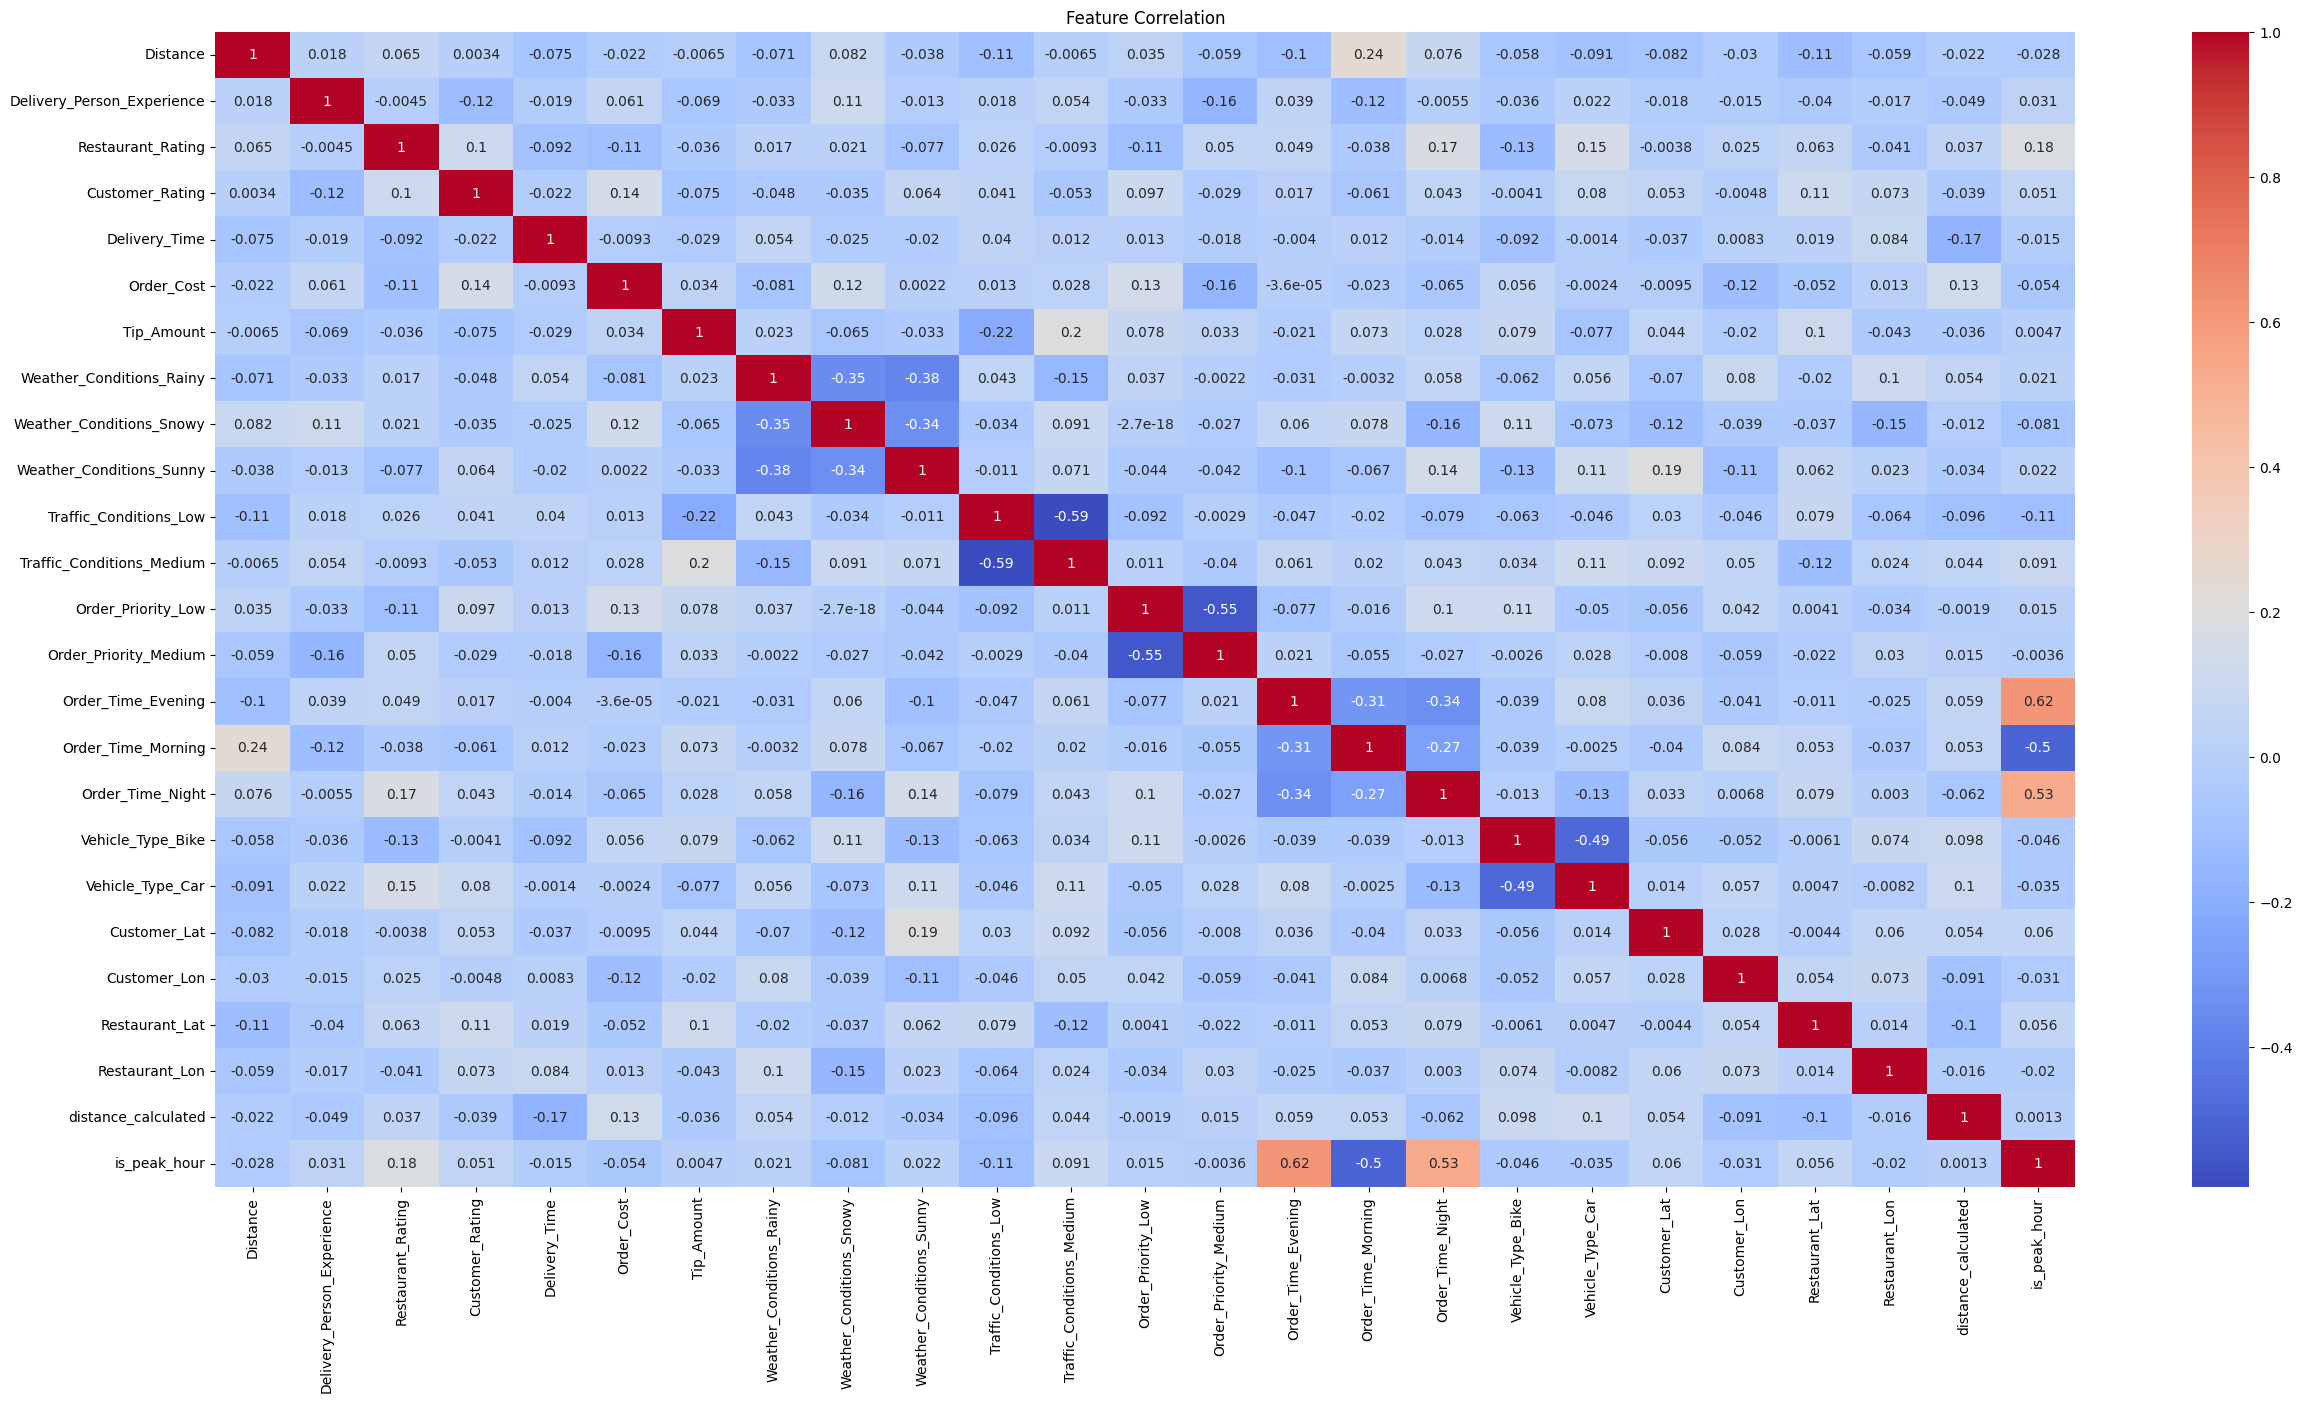

In [111]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(30,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")

save_plot('correlation_matrix.png')

plt.show()

Saved to -> ..\outputs\plots\\pair_plot.png


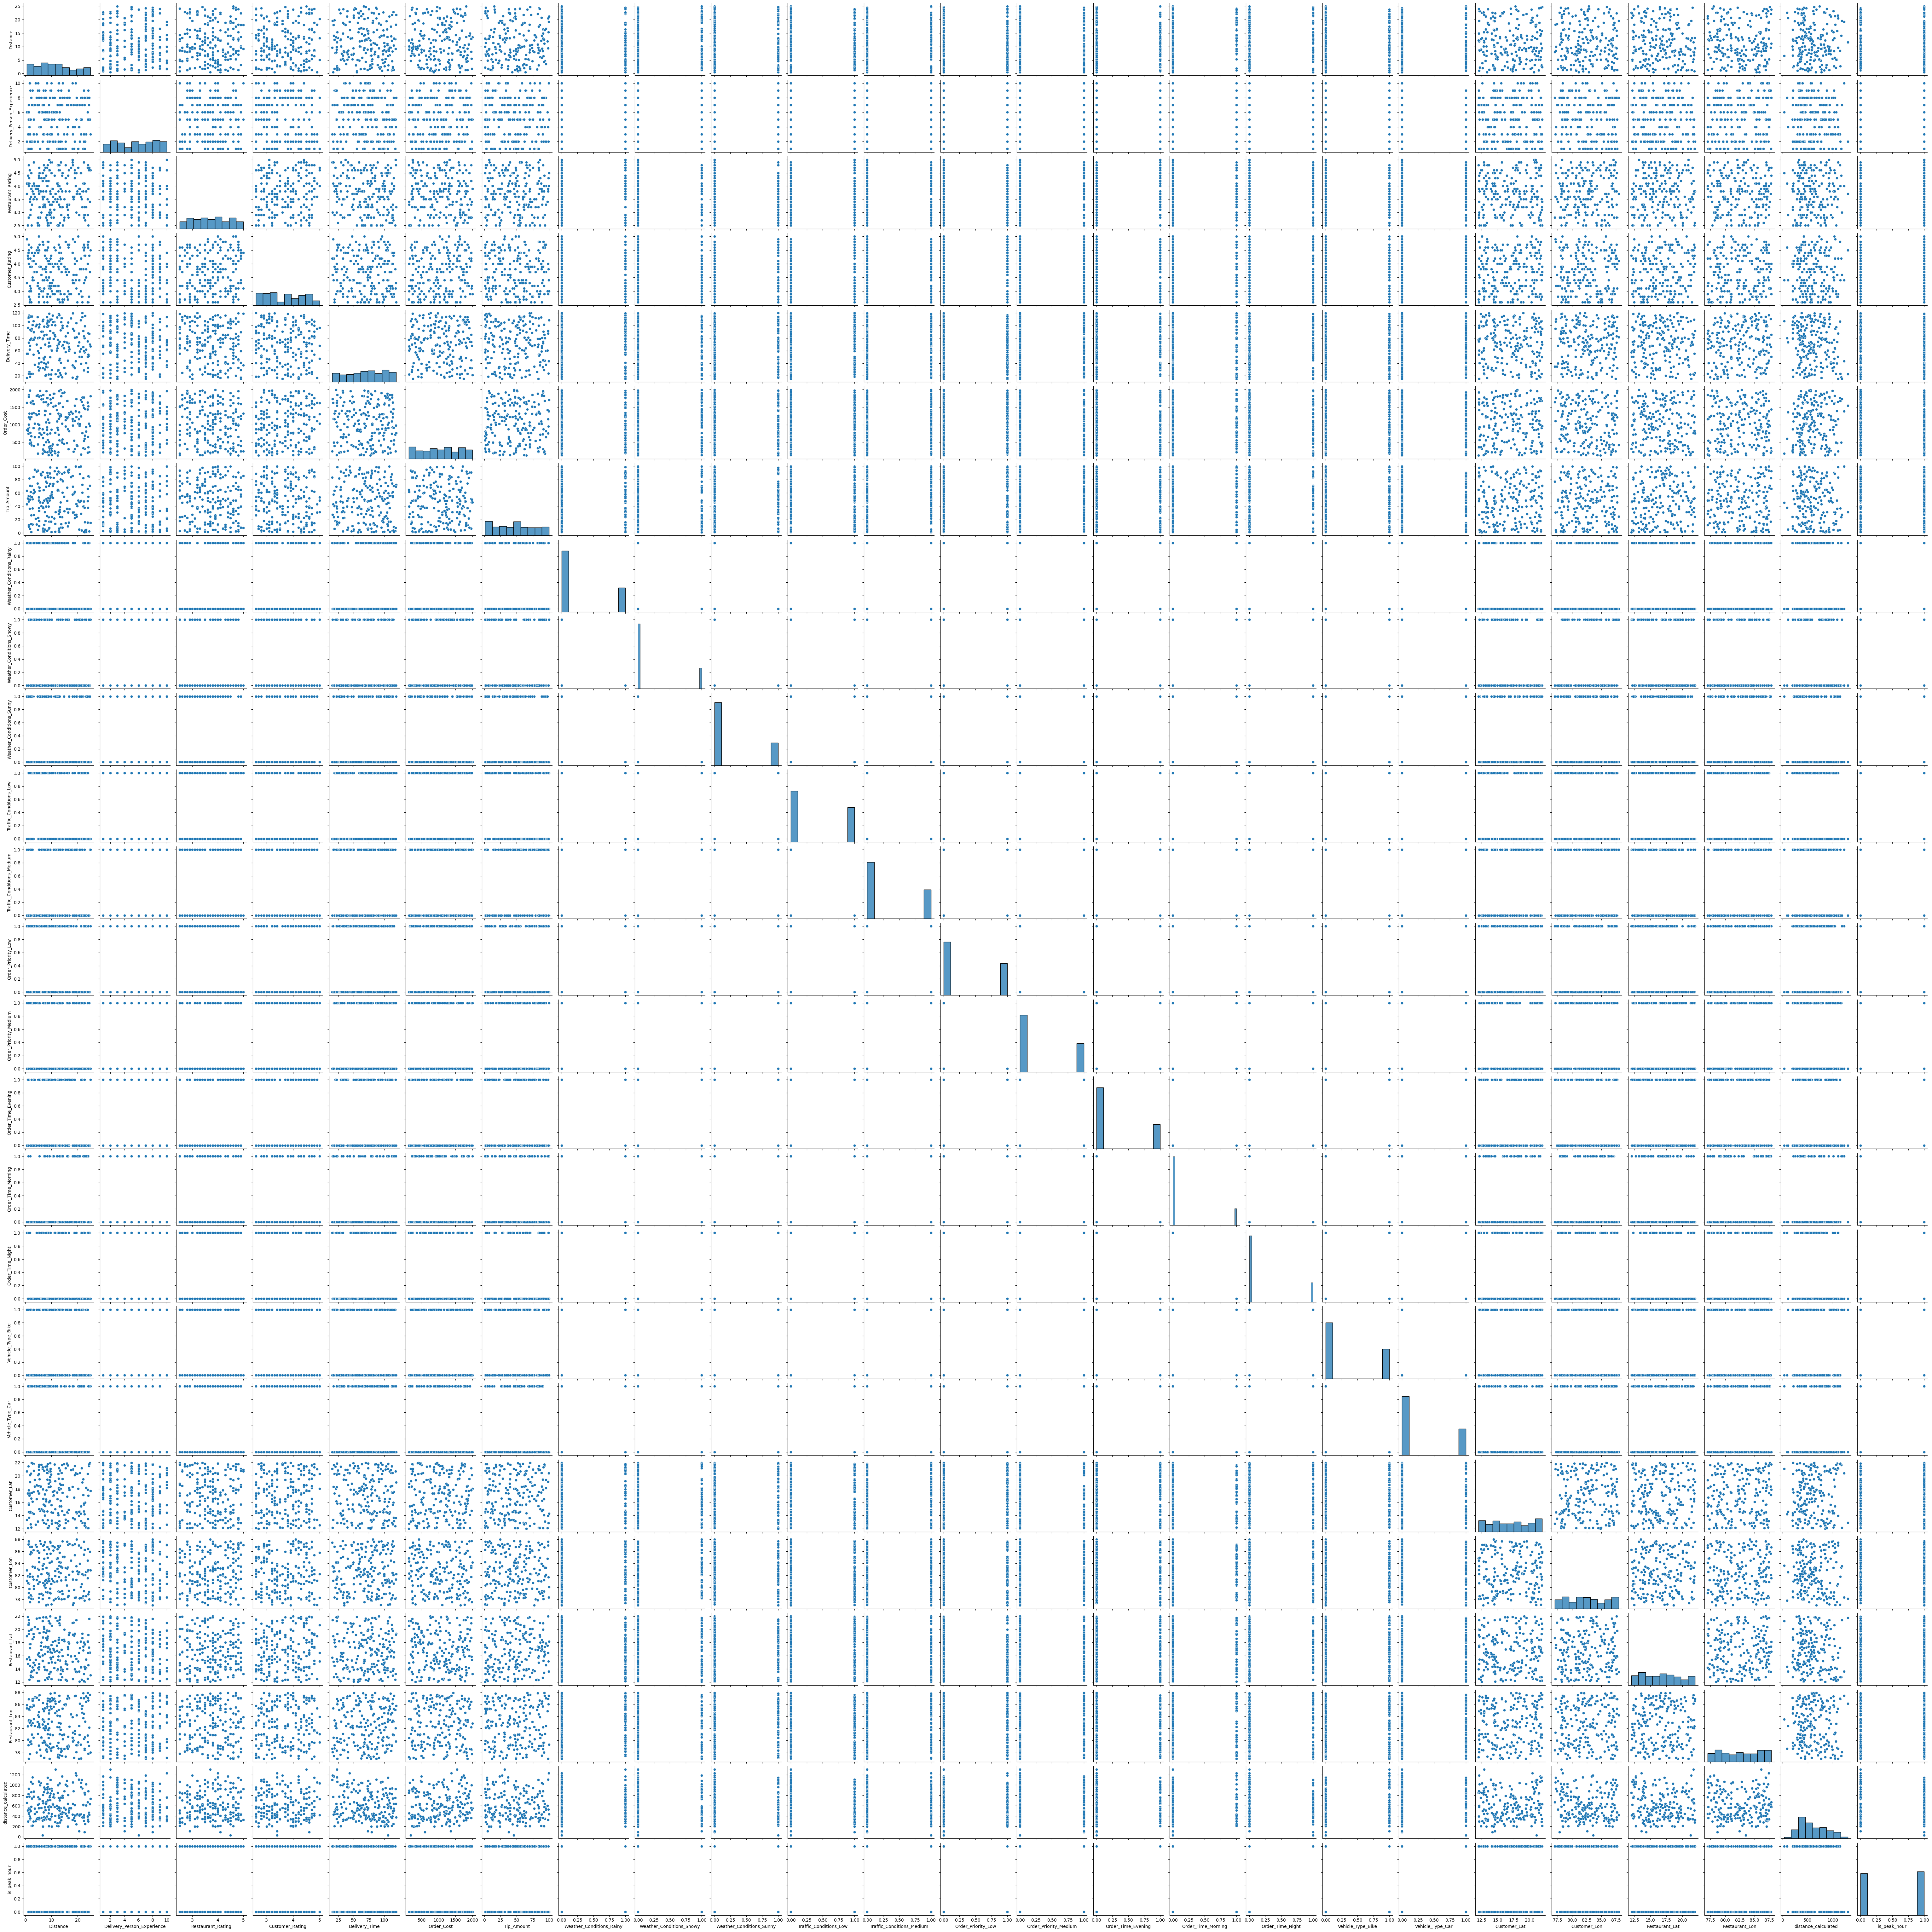

In [112]:
sns.pairplot(df)
save_plot('pair_plot.png')
plt.show()

Saved to -> ..\outputs\plots\\bar_graph.png


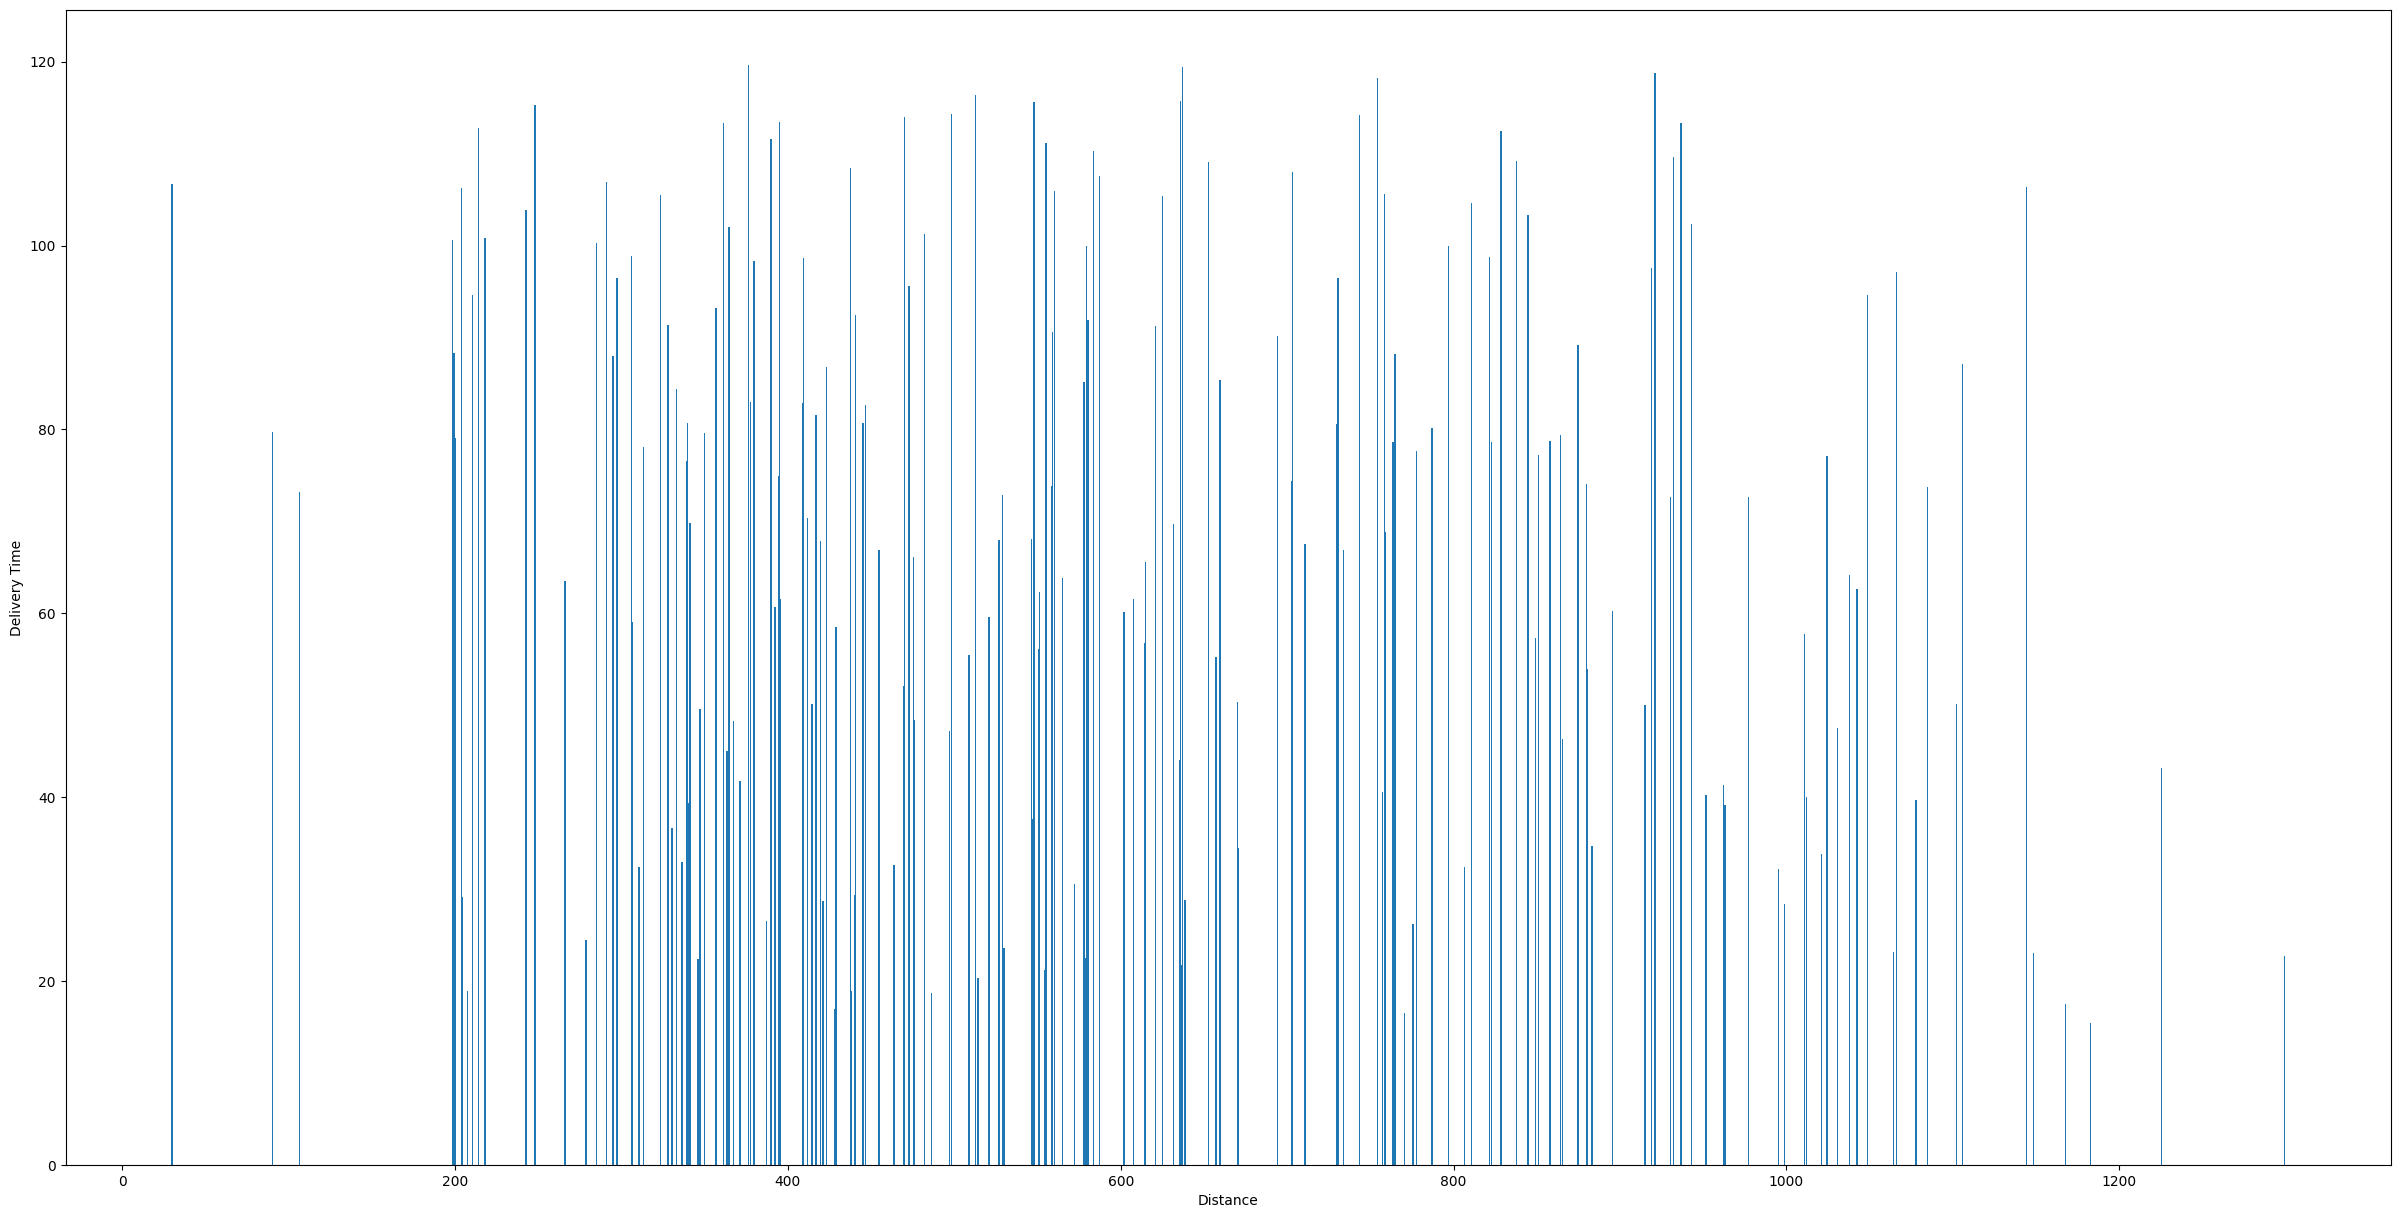

In [113]:
plt.figure(figsize=(30,15))
plt.bar(df['distance_calculated'], df['Delivery_Time'])
plt.title("")
plt.xlabel('Distance')
plt.ylabel('Delivery Time')
save_plot('bar_graph.png')
plt.show()

In [114]:
df.to_csv("..\data\processed\processed_data.csv", index=False)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\dell\AppData\Local\Temp\ipykernel_7904\1207683626.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df.to_csv("..\data\processed\processed_data.csv", index=False)
